<a href="https://colab.research.google.com/github/jashwanth-cse/Jashwanth-Codeboosters-Internship-2026/blob/main/Phase_01_Data_Engineering%20/Day_02_Database_SQL_Visualization/Day_02_Database_SQL_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("pandas version:",pd.__version__)
print("sqlite3 version:",sqlite3.version)

pandas version: 2.2.2
sqlite3 version: 2.6.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/student_performance.csv')
print(f"Dataset loaded:{df.shape[0]}students,{df.shape[1]} columns")
print(df.columns.tolist())



Dataset loaded:30students,13 columns
['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


In [ ]:
conn=sqlite3.connect('college1.db')
#college.db= the database file created in colab's filesystem
#if the file already exists it opens it

cursor=conn.cursor()
#cursor is a pen to write sql queries

df.to_sql(
    'students', # name of table
    conn, # which db connection to use
    if_exists='replace', #if table exists replace it
    index=False #Prevents pandas DataFrame index from becoming a database column
)

30

In [ ]:
cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
print(count)

30


In [ ]:
#PRAGMA is a special SQLite command(not std SQL)
#table.info() shows the structure of table
cursor.execute("PRAGMA table_info(students)")
columns_info=cursor.fetchall() #retreives all rows

print("Table structure of students:")
print(f"{'Column Name:':<25}{'Data Type':<12}")

print("-"*38)
for col in columns_info:
    print(f"{col[1]:<25}{col[2]:<12}")

Table structure of students:
Column Name:             Data Type   
--------------------------------------
student_id               INTEGER     
name                     TEXT        
age                      INTEGER     
gender                   TEXT        
department               TEXT        
semester                 INTEGER     
math_score               INTEGER     
science_score            INTEGER     
english_score            INTEGER     
programming_score        INTEGER     
attendance_percentage    INTEGER     
city                     TEXT        
admission_year           INTEGER     


In [ ]:
def run_query(sql, description=""):
  """
  Runs a SQL query and returns result as a Pandas DataFrame

  Parameters:
  -------------
  sql          :str - SQL query string to execute
  description  :str - A label to print above the results

  Returns:
  ----------
   Pandas DataFrame containing the query results
  """
  if description:
    print(f"\n{'='*55}")
    print(f"{description}")
    print(f"{'=*55'}")

  result=pd.read_sql_query(sql, conn)
  # 1.Executes the SQL query against the database(conn)
  # 2.Converts the result into Pandas DataFrame
  print(result.to_string(index=False))
  return result

1. Find total no. of students
2. Display all column names and datatypes using PRAGMA
3. Show first 5 rows from students table
4. Show students with math mark>80
5. Count number of male & female students



In [ ]:
query1="""
    SELECT student_id,name,department,math_score,attendance_percentage
    FROM students
    LIMIT 10
"""
res=run_query(query1)

 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [ ]:
query2="""
SELECT name,department,math_score
FROM students
ORDER BY math_score DESC
LIMIT 5
"""
res2=run_query(query2)

          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [ ]:
query3="""
SELECT name,math_score,science_score,programming_score,attendance_percentage
FROM students
WHERE department='Computer Science'
ORDER BY programming_score DESC
"""
res3=run_query(query3)

          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87
  Nisha Kapoor          79             84                 83                

In [ ]:
query4="""
SELECT name,department,attendance_percentage
FROM students
WHERE attendance_percentage>90
AND department!="Civil"
ORDER BY attendance_percentage DESC
"""
res4=run_query(query4)

          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91


In [ ]:
query5="""
SELECT department,
COUNT(*) AS total_students,
ROUND(AVG(math_score),2) AS avg_math_score,
ROUND(AVG(science_score),2) AS avg_science_score,
ROUND(AVG(programming_score),2) AS avg_programming_score,
ROUND(AVG(attendance_percentage),2) AS avg_attendance_percentage
FROM students
GROUP BY department
ORDER BY avg_math_score DESC
"""
res5=run_query(query5)

      department  total_students  avg_math_score  avg_science_score  avg_programming_score  avg_attendance_percentage
Computer Science              13           85.62              84.46                  89.23                      90.69
      Mechanical               6           71.00              76.50                  49.33                      83.50
     Electronics               6           71.00              74.17                  61.50                      80.33
           Civil               5           63.40              66.60                  40.60                      74.60


In [ ]:
query6="""
   SELECT
     department,
     ROUND(AVG(math_Score),2) AS avg_math,
     COUNT(*) AS students
  FROM students
  GROUP BY department
  HAVING (AVG(math_score)>70)
  ORDER BY avg_math DESC
  """
result6=run_query(query6,"Query 6:Departments with Average Math Score>70 (HAVING)")


Query 6:Departments with Average Math Score>70 (HAVING)
=*55
      department  avg_math  students
Computer Science     85.62        13
      Mechanical     71.00         6
     Electronics     71.00         6


In [ ]:
query7="""
  SELECT
     gender,
     COUNT(*) AS num_students,
     ROUND(AVG(math_Score),2) AS avg_math_score,
     ROUND(AVG(programming_Score),2) AS avg_programming_score,
     ROUND(AVG(attendance_percentage),2) AS avg_attendance_percentage
FROM students
GROUP BY gender
"""
result7=run_query(query7,"Query 7:Gender wise Performance Analysis")


Query 7:Gender wise Performance Analysis
=*55
gender  num_students  avg_math_score  avg_programming_score  avg_attendance_percentage
Female            15           78.47                   70.2                      88.53
  Male            15           73.67                   65.0                      80.47


In [ ]:
query8="""
    SELECT
      name,
      department,
      math_score+science_score+english_score+programming_score as total_score
    FROM students
    ORDER BY total_score DESC
    LIMIT 10
    """
result8=run_query(query8,"Top 10 students based on the Total Score")


Top 10 students based on the Total Score
=*55
          name       department  total_score
    Ananya Das Computer Science          371
   Tanvi Mehta Computer Science          367
Akanksha Yadav Computer Science          365
    Arjun Nair Computer Science          356
   Divya Singh Computer Science          356
Swati Kulkarni Computer Science          354
     Amit Bose Computer Science          336
    Suresh Rao Computer Science          334
  Nisha Kapoor Computer Science          327
  Aarav Sharma Computer Science          326


In [ ]:
dept_data={
    'dept_code':['CS','IT','ME','CIVIL'],
    'dept_name':['Computer Science','Information Technology','Mechanical','Civil'],
    'hod_name': ['Dr.Sharma','Dr.Reddy','Dr.Patel','Dr.Kumar'],
    'established': [1985,1988,1972,1965],
    'intake':[60,60,60,60]
}
dept_df=pd.DataFrame(dept_data)
dept_df.to_sql('departments',conn,if_exists='replace',index=False)
print("Created 'departments' table:")
print(dept_df.to_string(index=False))
dept_map={
    'Computer Science':'CS',
    'Electronics':'EC',
    'Mechanical':'ME',
    'Civil':'CE'

}
df['dept_code']=df['department'].map(dept_map)
df.to_sql('students',conn,if_exists='replace',index=False)
print("\nUpdated students table with dept_code column")
dept_map={
    'Computer Science':'CS',
    'Electronics':'EC',
    'Mechanical':'ME',
    'Civil':'CE'

}


Created 'departments' table:
dept_code              dept_name  hod_name  established  intake
       CS       Computer Science Dr.Sharma         1985      60
       IT Information Technology  Dr.Reddy         1988      60
       ME             Mechanical  Dr.Patel         1972      60
    CIVIL                  Civil  Dr.Kumar         1965      60

Updated students table with dept_code column


In [ ]:
query_join = """
SELECT
    s.name,
    s.math_score,
    d.dept_name,
    d.hod_name,
    d.established
FROM students AS s
INNER JOIN departments AS d
ON s.dept_code = d.dept_code
ORDER BY s.math_score DESC
LIMIT 8
"""

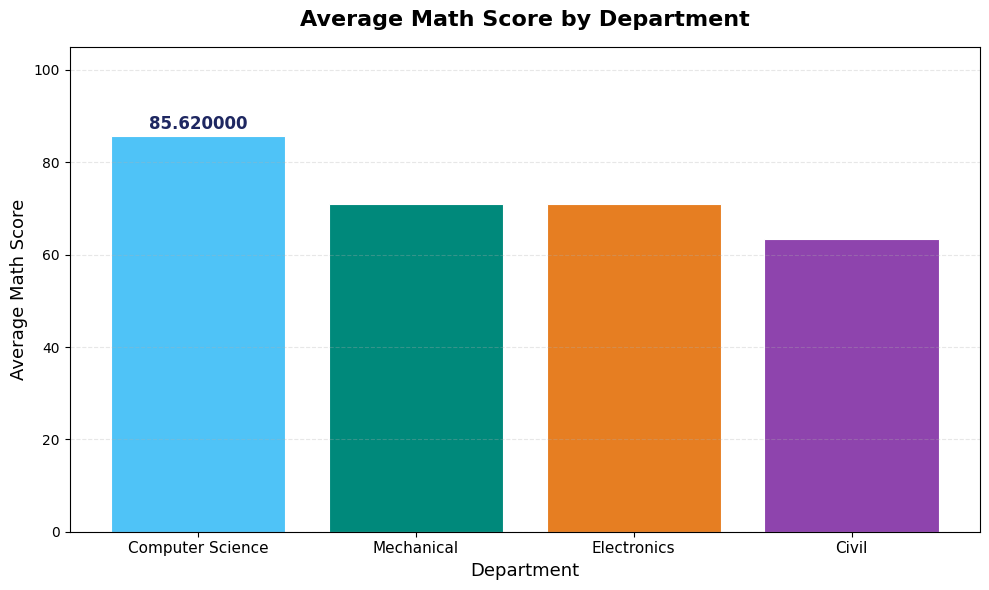

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
chart1_sql="""
SELECT department,ROUND(AVG(math_score),2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
chart1_data=pd.read_sql_query(chart1_sql,conn)
fig,ax=plt.subplots(figsize=(10,6))
bar_colours=['#4FC3F7','#00897B','#E67E22','#8E44AD']
bars=ax.bar(
    chart1_data['department'],
    chart1_data['avg_math'],
    color=bar_colours,
    edgecolor='white',
    linewidth=0.8
)
for bar in bars:
  height=bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height+0.8,
      f'{height:1f}',
      ha='center',va='bottom',
      fontsize=12,fontweight='bold',
      color='#1E2761'
  )
  ax.set_title('Average Math Score by Department',fontsize=16,fontweight='bold',pad=15)
  ax.set_xlabel('Department',fontsize=13)
  ax.set_ylabel('Average Math Score',fontsize=13)
  ax.set_ylim(0,105)
  ax.tick_params(axis='x',labelsize=11)
  ax.grid(axis='y',alpha=0.3,linestyle='--')
  plt.tight_layout()
  plt.show()

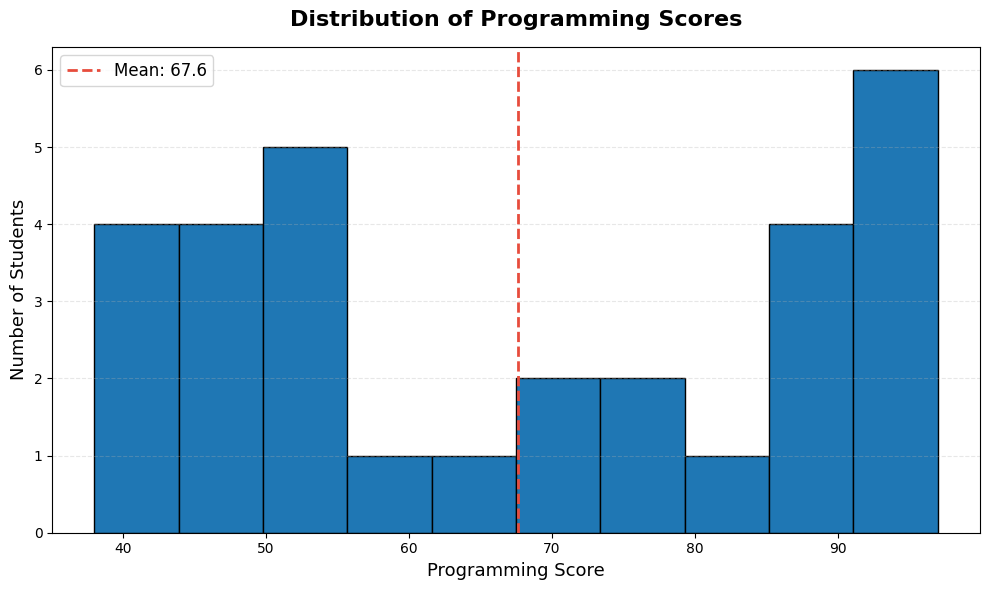

In [ ]:
prog_scores = df['programming_score'].tolist()

fig, ax = plt.subplots(figsize=(10,6))

# Histogram
ax.hist(prog_scores, bins=10, edgecolor='black')

mean_score = sum(prog_scores) / len(prog_scores)

ax.axvline(
    x=mean_score,
    color='#E74C3C',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {mean_score:.1f}'
)

# axvline = axis vertical line

ax.set_title(
    'Distribution of Programming Scores',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Programming Score', fontsize=13)
ax.set_ylabel('Number of Students', fontsize=13)

ax.legend(fontsize=12)

ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Sample dataset (replace with your own CSV)
df = pd.DataFrame({
'Category': np.random. choice(['A','B','C','D'], 100),
'Value': np.random.randint(10, 100, 100),
'Score': np.random.randint(1, 10, 100)

})

df.head()

,Category,Value,Score
0,D,96,7
1,B,79,2
2,D,87,8
3,B,38,5
4,D,24,7


1.  Write a SQL query to find the average programming score for female students only.
2. What is the difference between WHERE and HAVING? Write one example of each using the students table.

2. Write a SQL query to find all departments where the average attendance is above 85%.

4. What does pd.read_sq1_query() return? What two arguments does it require?
5. Modify Chart 1 (bar chart) to show average PROGRAMMING scores instead of math scores.

In [ ]:
query9="""
SELECT AVG(programming_score)
FROM students
WHERE gender="Female"
"""
run_query(query9)

 AVG(programming_score)
                   70.2


,AVG(programming_score)
0,70.2


**WHERE**
It is a conditional clause, it filters data before grouping

ex:filter students with female gender

**HAVING **
It is use with aggregate functions
ex:group students with same average mark

In [ ]:
query10="""
SELECT department
FROM students
WHERE attendance_percentage>85
GROUP BY department
"""
run_query(query10)


      department
Computer Science
     Electronics
      Mechanical


,department
0,Computer Science
1,Electronics
2,Mechanical
